# Day 3 — Cross-Validation, Tuning, and Calibration

Day 2 produced one number from one split: **ROC-AUC 0.958**, against 0.945 for a single cut on
spectral index. Three things about that number are not yet trustworthy, and today fixes each:

1. **It has no error bar.** It came from 427 test sources. A different random split gives a
   different number, and we do not yet know whether the margin over the physics baseline
   (+0.013) is real or noise.
2. **The hyperparameters were guesses.** `max_depth=8`, `min_samples_leaf=5`,
   `n_estimators=400` were conservative judgment calls, not the product of any search.
3. **The probabilities are uninterpreted.** Day 5 plans to threshold `P(FSRQ)` to decide which
   BCUs we are confident about. That is only meaningful if 0.9 actually means 90%.

### Today
1. Repeated stratified cross-validation → AUC ± σ, **paired** against the physics baseline.
2. Grid search over `max_depth` × `min_samples_leaf`, scored by CV on the training set only.
3. Reliability curves and Brier scores; sigmoid vs isotonic calibration.
4. One final evaluation on the *same* held-out test set Day 2 used, so the numbers compare.

### Deliberately not today
No SHAP (Day 4), no BCU predictions (Day 5). The BCU file stays closed.

## 1. Setup

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold, GridSearchCV,
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix,
)

RANDOM_STATE = 42          # same seed as Day 2, so the split is identical

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="ticks", context="notebook")
CLASS_COLORS = {"bll": "#2E86AB", "fsrq": "#D1495B"}
RF_COLOR, GAMMA_COLOR = "#2E86AB", "#E1A100"

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

In [2]:
known_path = PROCESSED / "known_blazars.csv"
if not known_path.exists():
    raise FileNotFoundError(
        f"{known_path} not found — run notebooks/01_initial_data_exploration.ipynb first."
    )

known = pd.read_csv(known_path)

FEATURES = ["PL_Index", "log10_Variability_Index", "log10_Flux1000", "Pivot_Energy"]
LABEL = "CLASS_clean"

X = known[FEATURES]
y = (known[LABEL] == "fsrq").astype(int)      # 1 = FSRQ (positive, minority)

print(f"{len(known)} labelled blazars | {y.sum()} FSRQ, {(~y.astype(bool)).sum()} BL Lac")
print(f"imbalance {(~y.astype(bool)).sum() / y.sum():.2f} : 1")

2134 labelled blazars | 755 FSRQ, 1379 BL Lac
imbalance 1.83 : 1


### 1.1 Reconstructing the Day 2 split

Same call, same seed, so `X_test` here is byte-for-byte the 427 sources Day 2 held out. This
matters: the *only* honest way to compare today's tuned model against Day 2's baseline is on
identical test data.

Everything in sections 2 and 3 — every fold, every grid point — is computed on `X_train` only.
The test set is opened once, in section 5.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Day 2's hyperparameters, kept as the reference point to beat.
DAY2_PARAMS = dict(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

print(f"train {len(X_train)}  |  test {len(X_test)}")
print(f"train FSRQ fraction {y_train.mean():.4f}  |  test FSRQ fraction {y_test.mean():.4f}")

train 1707  |  test 427
train FSRQ fraction 0.3538  |  test FSRQ fraction 0.3536


## 2. How much of 0.958 is noise?

### 2.1 What we are actually comparing

A note on the baseline first, because Day 2 was loose about it. "A single cut at Γ > 2.2" has
an ROC-AUC of 0.945 — but **ROC-AUC does not depend on the threshold at all**. AUC measures how
well a score *ranks* sources; 2.2 versus 2.3 versus 2.15 changes precision and recall but leaves
AUC untouched.

So the honest statement is: *`PL_Index` used alone as a ranking score* achieves AUC 0.945. The
threshold only enters when we convert the ranking into a decision.

That reframing sharpens the research question. The comparison is no longer
"forest vs. a line someone drew" but:

> **Do `Variability_Index`, `Flux1000`, and `Pivot_Energy` add any ranking power beyond spectral
> index alone?**

Because both models are scored on exactly the same folds, we can subtract them fold by fold —
a **paired** comparison, which cancels the fold-to-fold difficulty that dominates the variance.

In [4]:
# Score the RF and PL_Index-alone on identical folds so the two can be subtracted.
def paired_cv(cv, X, y, params):
    rows = []
    for i, (tr, te) in enumerate(cv.split(X, y)):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y.iloc[tr], y.iloc[te]

        rf = RandomForestClassifier(n_jobs=-1, **params).fit(Xtr, ytr)
        p_rf = rf.predict_proba(Xte)[:, 1]

        # No fitting needed: higher Gamma means "more FSRQ-like", so PL_Index *is* the score.
        p_gamma = Xte["PL_Index"].to_numpy()

        rows.append({
            "fold": i,
            "rf_auc": roc_auc_score(yte, p_rf),
            "gamma_auc": roc_auc_score(yte, p_gamma),
            "rf_ap": average_precision_score(yte, p_rf),
            "gamma_ap": average_precision_score(yte, p_gamma),
        })
    out = pd.DataFrame(rows)
    out["auc_diff"] = out["rf_auc"] - out["gamma_auc"]
    out["ap_diff"] = out["rf_ap"] - out["gamma_ap"]
    return out

### 2.2 A single 5-fold pass

Five folds, each source used for testing exactly once. These five numbers are genuinely
independent test sets (though not independent *training* sets, which share 60% of their rows).

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv5 = paired_cv(skf, X_train, y_train, DAY2_PARAMS)

print(cv5.round(4).to_string(index=False))
print()
print(f"RF        AUC = {cv5['rf_auc'].mean():.4f} ± {cv5['rf_auc'].std(ddof=1):.4f}")
print(f"Gamma     AUC = {cv5['gamma_auc'].mean():.4f} ± {cv5['gamma_auc'].std(ddof=1):.4f}")
print(f"paired diff   = {cv5['auc_diff'].mean():+.4f} ± {cv5['auc_diff'].std(ddof=1):.4f}")

 fold  rf_auc  gamma_auc  rf_ap  gamma_ap  auc_diff  ap_diff
    0  0.9467     0.9326 0.9172    0.8539    0.0142   0.0633
    1  0.9436     0.9301 0.9216    0.8854    0.0135   0.0362
    2  0.9579     0.9416 0.9317    0.8976    0.0163   0.0340
    3  0.9500     0.9412 0.9348    0.8741    0.0088   0.0607
    4  0.9235     0.8971 0.8972    0.8328    0.0264   0.0645

RF        AUC = 0.9444 ± 0.0128
Gamma     AUC = 0.9285 ± 0.0183
paired diff   = +0.0158 ± 0.0065


### 2.3 Repeated CV for a stabler estimate

Five folds give a noisy standard deviation. Repeating the whole 5-fold procedure with ten
different shuffles gives 50 measurements and a much steadier *mean*.

One caveat, stated plainly: these 50 folds are **not independent** — they reuse the same 1,707
sources over and over. So `std / sqrt(50)` is *not* a valid standard error, and a paired t-test
on these 50 rows would be anti-conservative. Use repeated CV to pin down the point estimate;
use the spread descriptively, not inferentially.

In [6]:
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
cv50 = paired_cv(rskf, X_train, y_train, DAY2_PARAMS)

summary = pd.DataFrame({
    "mean": [cv50["rf_auc"].mean(), cv50["gamma_auc"].mean(), cv50["auc_diff"].mean()],
    "std":  [cv50["rf_auc"].std(ddof=1), cv50["gamma_auc"].std(ddof=1), cv50["auc_diff"].std(ddof=1)],
    "min":  [cv50["rf_auc"].min(), cv50["gamma_auc"].min(), cv50["auc_diff"].min()],
    "max":  [cv50["rf_auc"].max(), cv50["gamma_auc"].max(), cv50["auc_diff"].max()],
}, index=["Random Forest", "PL_Index alone", "difference (paired)"])

wins = (cv50["auc_diff"] > 0).sum()
print(summary.round(4).to_string())
print()
print(f"RF ranked better than PL_Index alone in {wins}/{len(cv50)} folds")
print(f"mean AP gain: {cv50['ap_diff'].mean():+.4f}")

                       mean     std     min     max
Random Forest        0.9460  0.0092  0.9235  0.9660
PL_Index alone       0.9298  0.0103  0.8971  0.9538
difference (paired)  0.0163  0.0069  0.0021  0.0297

RF ranked better than PL_Index alone in 50/50 folds
mean AP gain: +0.0527


### 2.4 The figure that carries this section

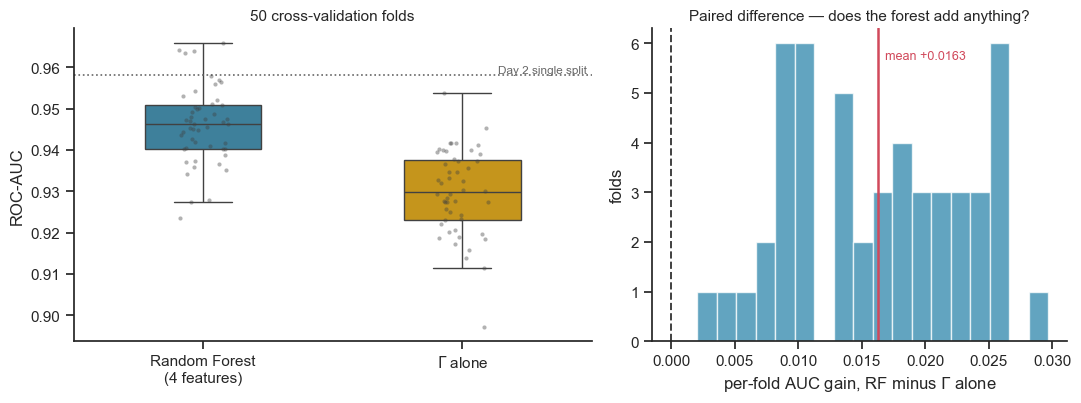

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.25, 1]})

# --- left: the two AUC distributions, unpaired view ---
ax = axes[0]
long = cv50.melt(value_vars=["rf_auc", "gamma_auc"], var_name="model", value_name="auc")
long["model"] = long["model"].map({"rf_auc": "Random Forest\n(4 features)",
                                   "gamma_auc": r"$\Gamma$ alone"})
sns.boxplot(data=long, x="model", y="auc", hue="model", ax=ax, width=0.45,
            palette=[RF_COLOR, GAMMA_COLOR], showfliers=False, legend=False)
sns.stripplot(data=long, x="model", y="auc", ax=ax, size=3, alpha=0.4, color="0.25")
ax.axhline(0.958, color="0.4", ls=":", lw=1.2)
ax.text(1.48, 0.9582, "Day 2 single split", color="0.4", fontsize=8.5,
        ha="right", va="bottom")
ax.set_ylabel("ROC-AUC")
ax.set_xlabel("")
ax.set_title("50 cross-validation folds", fontsize=11)

# --- right: the paired difference, which is the actual result ---
ax = axes[1]
ax.hist(cv50["auc_diff"], bins=18, color=RF_COLOR, alpha=0.75, edgecolor="white")
ax.axvline(0, color="0.25", ls="--", lw=1.4)
ax.axvline(cv50["auc_diff"].mean(), color="#D1495B", lw=1.8)
ax.text(cv50["auc_diff"].mean(), ax.get_ylim()[1] * 0.93,
        f"  mean {cv50['auc_diff'].mean():+.4f}", color="#D1495B", fontsize=9, va="top")
ax.set_xlabel("per-fold AUC gain, RF minus " + r"$\Gamma$ alone")
ax.set_ylabel("folds")
ax.set_title("Paired difference — does the forest add anything?", fontsize=11)

sns.despine(fig=fig)
fig.tight_layout()
fig.savefig(FIGURES / "cv_auc_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Tuning: replacing the guesses with a search

### 3.1 What is worth tuning, and what is not

`n_estimators` is **not** a hyperparameter to search. A Random Forest averages independent
trees; adding more trees only reduces the variance of that average, and the out-of-sample
error decreases monotonically to an asymptote. More trees cannot overfit — they just cost time.
400 is past the plateau for a 4-feature problem, so it stays fixed.

The two that genuinely trade off are:

- **`max_depth`** — how many splits a single tree may stack. Deep trees carve out small,
  possibly spurious regions of feature space.
- **`min_samples_leaf`** — the minimum sources a leaf must contain. This is the more direct
  control: a leaf holding 20 sources cannot represent a single outlier.

30 combinations, each scored by 5-fold CV on the training set. `n_jobs` sits on the search, not
on the forest, so the two do not fight over cores.

In [8]:
param_grid = {
    "max_depth": [3, 4, 6, 8, 12, None],
    "min_samples_leaf": [1, 2, 5, 10, 20],
}

base = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=1,                       # parallelism lives on the search instead
)

search = GridSearchCV(
    base,
    param_grid,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train)

print("best params:", search.best_params_)
print(f"best CV AUC: {search.best_score_:.4f}")

best params: {'max_depth': 4, 'min_samples_leaf': 2}
best CV AUC: 0.9477


### 3.2 The search surface

Read this heatmap for *flatness*, not for the winner. If every cell sits within a hair of every
other, the honest conclusion is that this problem does not care about these knobs — and the
"best" cell is then just the luckiest draw from noise, not a discovery.

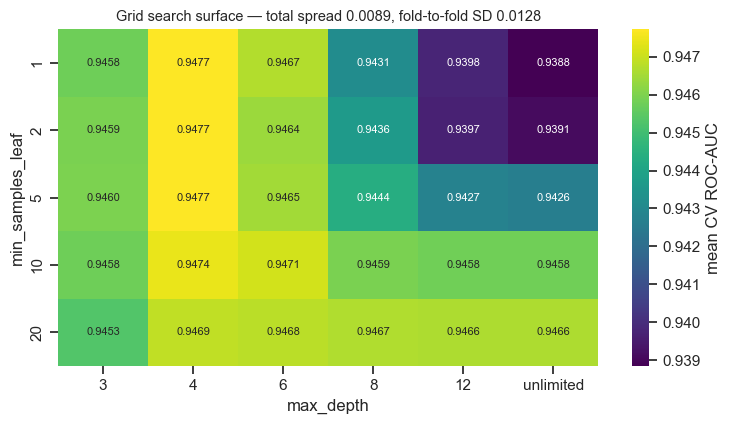

In [9]:
res = pd.DataFrame(search.cv_results_)
res["max_depth_lbl"] = res["param_max_depth"].astype(str).replace("None", "unlimited")

grid = res.pivot_table(index="param_min_samples_leaf",
                       columns="max_depth_lbl", values="mean_test_score")
grid = grid[[c for c in ["3", "4", "6", "8", "12", "unlimited"] if c in grid.columns]]

spread = res["mean_test_score"].max() - res["mean_test_score"].min()
fold_sd = cv5["rf_auc"].std(ddof=1)

fig, ax = plt.subplots(figsize=(7.6, 4.4))
sns.heatmap(grid, annot=True, fmt=".4f", cmap="viridis", ax=ax,
            cbar_kws={"label": "mean CV ROC-AUC"}, annot_kws={"size": 8})
ax.set_xlabel("max_depth")
ax.set_ylabel("min_samples_leaf")
ax.set_title(f"Grid search surface — total spread {spread:.4f}, "
             f"fold-to-fold SD {fold_sd:.4f}", fontsize=10.5)
fig.tight_layout()
fig.savefig(FIGURES / "tuning_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3 Is the winner actually better than Day 2's guess?

Comparing the best grid cell against the Day 2 cell on the *same* CV folds. If the gap is small
relative to the fold-to-fold scatter above, then Day 2's guess was already fine and we should
say so rather than dressing up a noise-level change as tuning.

In [10]:
day2_row = res[(res["param_max_depth"] == 8) & (res["param_min_samples_leaf"] == 5)]
day2_cv = day2_row["mean_test_score"].iloc[0]

print(f"Day 2 guess   (depth=8,  leaf=5)  CV AUC = {day2_cv:.4f}")
print(f"Grid winner   {search.best_params_}  CV AUC = {search.best_score_:.4f}")
print(f"gain from tuning = {search.best_score_ - day2_cv:+.4f}")
print(f"fold-to-fold SD  = {fold_sd:.4f}   <- the gain has to clear this to mean anything")
print()
print("top 5 cells:")
print(
    res.nlargest(5, "mean_test_score")[
        ["param_max_depth", "param_min_samples_leaf", "mean_test_score", "std_test_score"]
    ].to_string(index=False)
)

BEST_PARAMS = dict(
    n_estimators=400,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    **search.best_params_,
)

Day 2 guess   (depth=8,  leaf=5)  CV AUC = 0.9444
Grid winner   {'max_depth': 4, 'min_samples_leaf': 2}  CV AUC = 0.9477
gain from tuning = +0.0034
fold-to-fold SD  = 0.0128   <- the gain has to clear this to mean anything

top 5 cells:
param_max_depth  param_min_samples_leaf  mean_test_score  std_test_score
              4                       2         0.947722        0.011704
              4                       1         0.947720        0.012049
              4                       5         0.947706        0.012038
              4                      10         0.947438        0.011763
              6                      10         0.947125        0.011485


## 4. Calibration — do the probabilities mean anything?

Day 5 wants to say *"we are confident about this BCU"* by thresholding `P(FSRQ)`. That sentence
is only defensible if, among sources the model scores 0.9, roughly 90% really are FSRQs.

Two reasons to expect the raw forest to fail this:

1. **Averaging pulls toward the middle.** A probability of 1.0 requires every one of 400 trees
   to agree. Confident regions get shrunk toward 0.5, which makes the forest *under*-confident
   at the extremes.
2. **`class_weight="balanced"` deliberately breaks the base rate.** It tells the forest to act
   as if FSRQs and BL Lacs were equally common when they are 1:1.83. That is the right call for
   *ranking* and recall, but it systematically inflates `P(FSRQ)` relative to the true prior.

The second effect should dominate and push the reliability curve **below** the diagonal
(predicted probability higher than observed frequency). Writing that prediction down before
plotting, same as the Day 1 pre-registration.

In [11]:
def reliability(y_true, p, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=n_bins, strategy="quantile")
    return mean_pred, frac_pos

# Calibrators are fit by internal CV on the training set — the test set stays closed.
cal_models = {
    "uncalibrated": RandomForestClassifier(n_jobs=-1, **BEST_PARAMS),
    "sigmoid (Platt)": CalibratedClassifierCV(
        RandomForestClassifier(n_jobs=-1, **BEST_PARAMS), method="sigmoid", cv=5),
    "isotonic": CalibratedClassifierCV(
        RandomForestClassifier(n_jobs=-1, **BEST_PARAMS), method="isotonic", cv=5),
}

fitted, probs = {}, {}
for name, m in cal_models.items():
    m.fit(X_train, y_train)
    fitted[name] = m
    probs[name] = m.predict_proba(X_test)[:, 1]

cal_table = pd.DataFrame({
    "Brier score": {n: brier_score_loss(y_test, p) for n, p in probs.items()},
    "ROC-AUC":     {n: roc_auc_score(y_test, p) for n, p in probs.items()},
    "mean P(FSRQ)": {n: p.mean() for n, p in probs.items()},
})
cal_table.loc[:, "true FSRQ rate"] = y_test.mean()
print(cal_table.round(4).to_string())

                 Brier score  ROC-AUC  mean P(FSRQ)  true FSRQ rate
uncalibrated          0.0779   0.9598        0.3884          0.3536
sigmoid (Platt)       0.0797   0.9600        0.3449          0.3536
isotonic              0.0742   0.9596        0.3449          0.3536


Three things to read off that table.

**The pre-registered prediction holds.** The raw forest's mean `P(FSRQ)` is **0.388** against a
true test-set FSRQ rate of **0.354** — it systematically over-states FSRQ probability, exactly as
`class_weight="balanced"` implies it should. Both calibrators pull the mean to 0.345, essentially
onto the true base rate.

**Brier score** is the mean squared error of the probabilities — lower is better, and unlike AUC
it punishes being confidently wrong. It is the number that matters for Day 5. Isotonic wins
(0.0742 vs 0.0779 raw); Platt scaling actually makes it slightly *worse* (0.0797), because the
logistic curve it is restricted to fitting is the wrong shape for the forest's S-bend.

**AUC barely moves under calibration — but be careful about why.** A *single* fitted Platt
sigmoid is strictly increasing, and a strictly increasing map cannot reorder anything, so
applying one to a fixed score vector leaves AUC exactly unchanged. That is not quite what
`CalibratedClassifierCV(cv=5)` does: it splits the training set five ways and fits a separate
forest *and* a separate calibrator on each, then averages the five calibrated outputs. Both the
underlying scores and the mapping differ across folds, so the averaged score is **not** a
monotonic function of the original one, and AUC drifts — here by ±0.0004, which is noise. The
principle survives where it matters: calibration changes what the probabilities *mean*, not how
well they rank.

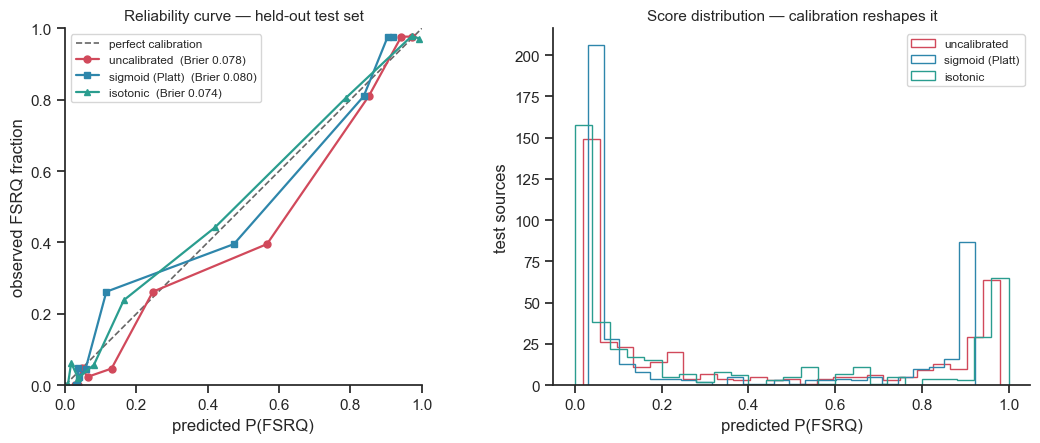

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6),
                         gridspec_kw={"width_ratios": [1, 1]})

# --- left: reliability curves ---
ax = axes[0]
ax.plot([0, 1], [0, 1], ls="--", color="0.4", lw=1.2, label="perfect calibration")
styles = {"uncalibrated": ("o-", "#D1495B"), "sigmoid (Platt)": ("s-", RF_COLOR),
          "isotonic": ("^-", "#2A9D8F")}
for name, p in probs.items():
    mp, fp = reliability(y_test, p, n_bins=10)
    fmt, col = styles[name]
    ax.plot(mp, fp, fmt, color=col, lw=1.6, ms=5,
            label=f"{name}  (Brier {brier_score_loss(y_test, p):.3f})")
ax.set_xlabel("predicted P(FSRQ)")
ax.set_ylabel("observed FSRQ fraction")
ax.set_title("Reliability curve — held-out test set", fontsize=11)
ax.legend(fontsize=8.5, loc="upper left")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect("equal")

# --- right: where the probability mass actually sits ---
ax = axes[1]
for name, p in probs.items():
    _, col = styles[name]
    ax.hist(p, bins=25, histtype="step", lw=1.8, color=col, label=name)
ax.set_xlabel("predicted P(FSRQ)")
ax.set_ylabel("test sources")
ax.set_title("Score distribution — calibration reshapes it", fontsize=11)
ax.legend(fontsize=8.5)

sns.despine(fig=fig)
fig.tight_layout()
fig.savefig(FIGURES / "calibration_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.1 What this means for the Day 5 confidence threshold

Day 5 will keep only BCUs whose probability clears some threshold and leave the rest labelled
*unknown*. The table below asks the question that actually matters: **at each threshold, what
fraction of the sources we keep do we get right?** That is precision on the confident subset,
measured on the held-out test set using whichever calibration won above.

In [13]:
BEST_CAL = min(probs, key=lambda n: brier_score_loss(y_test, probs[n]))
p_best = probs[BEST_CAL]
print(f"lowest Brier score: {BEST_CAL}\n")

rows = []
for t in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]:
    confident = (p_best >= t) | (p_best <= 1 - t)     # confident either way
    kept = confident.sum()
    if kept == 0:
        continue
    pred = (p_best[confident] >= 0.5).astype(int)
    rows.append({
        "threshold": t,
        "kept": kept,
        "kept %": 100 * kept / len(p_best),
        "accuracy on kept": (pred == y_test[confident]).mean(),
    })

thresh_table = pd.DataFrame(rows)
print(thresh_table.round(3).to_string(index=False))

lowest Brier score: isotonic

 threshold  kept  kept %  accuracy on kept
      0.50   427 100.000             0.888
      0.60   407  95.316             0.909
      0.70   373  87.354             0.938
      0.80   355  83.138             0.955
      0.90   309  72.365             0.977
      0.95   258  60.422             0.981


## 5. One evaluation on the held-out test set

Everything above used training data only. This is the single opening of the test set — the same
427 sources Day 2 used, so these numbers sit directly beside Day 2's.

In [14]:
final = fitted[BEST_CAL]
p_final = probs[BEST_CAL]
pred_final = (p_final >= 0.5).astype(int)

# Day 2's model, refit here so the comparison is like-for-like.
day2_rf = RandomForestClassifier(n_jobs=-1, **DAY2_PARAMS).fit(X_train, y_train)
p_day2 = day2_rf.predict_proba(X_test)[:, 1]

# The physics baseline, as a ranker and as a decision rule.
p_gamma_test = X_test["PL_Index"].to_numpy()
pred_gamma = (X_test["PL_Index"] > 2.2).astype(int)


def summarise(name, y_true, pred, score):
    rep = classification_report(y_true, pred, output_dict=True, zero_division=0)
    return {
        "model": name,
        "accuracy": rep["accuracy"],
        "FSRQ precision": rep["1"]["precision"],
        "FSRQ recall": rep["1"]["recall"],
        "FSRQ f1": rep["1"]["f1-score"],
        "ROC-AUC": roc_auc_score(y_true, score),
        "avg precision": average_precision_score(y_true, score),
    }


comparison = pd.DataFrame([
    summarise("Cut at PL_Index > 2.2", y_test, pred_gamma, p_gamma_test),
    summarise("Day 2 RF (guessed params)", y_test, (p_day2 >= 0.5).astype(int), p_day2),
    summarise(f"Day 3 RF (tuned + {BEST_CAL})", y_test, pred_final, p_final),
]).set_index("model")

print(comparison.round(4).to_string())

                             accuracy  FSRQ precision  FSRQ recall  FSRQ f1  ROC-AUC  avg precision
model                                                                                              
Cut at PL_Index > 2.2          0.8618          0.7447       0.9272   0.8260   0.9447         0.8966
Day 2 RF (guessed params)      0.8876          0.8323       0.8543   0.8431   0.9578         0.9336
Day 3 RF (tuned + isotonic)    0.8876          0.8601       0.8146   0.8367   0.9596         0.9305


In [15]:
cm = confusion_matrix(y_test, pred_final)
cm_df = pd.DataFrame(cm,
                     index=["true BL Lac", "true FSRQ"],
                     columns=["pred BL Lac", "pred FSRQ"])
print(cm_df.to_string())
print()
print(classification_report(y_test, pred_final,
                            target_names=["BL Lac", "FSRQ"], digits=3))

             pred BL Lac  pred FSRQ
true BL Lac          256         20
true FSRQ             28        123

              precision    recall  f1-score   support

      BL Lac      0.901     0.928     0.914       276
        FSRQ      0.860     0.815     0.837       151

    accuracy                          0.888       427
   macro avg      0.881     0.871     0.876       427
weighted avg      0.887     0.888     0.887       427



## 6. Saving what Day 4 and Day 5 need

In [16]:
artifacts = {
    "random_state": RANDOM_STATE,
    "features": FEATURES,
    "best_params": {k: (v if v is not None else None) for k, v in BEST_PARAMS.items()},
    "calibration": BEST_CAL,
    "cv_rf_auc_mean": float(cv50["rf_auc"].mean()),
    "cv_rf_auc_std": float(cv50["rf_auc"].std(ddof=1)),
    "cv_gamma_auc_mean": float(cv50["gamma_auc"].mean()),
    "cv_gamma_auc_std": float(cv50["gamma_auc"].std(ddof=1)),
    "cv_paired_diff_mean": float(cv50["auc_diff"].mean()),
    "cv_paired_diff_std": float(cv50["auc_diff"].std(ddof=1)),
    "cv_folds_rf_won": int((cv50["auc_diff"] > 0).sum()),
    "cv_folds_total": int(len(cv50)),
    "tuning_gain_over_day2": float(search.best_score_ - day2_cv),
    "test_roc_auc": float(roc_auc_score(y_test, p_final)),
    "test_brier": float(brier_score_loss(y_test, p_final)),
}

with open(PROCESSED / "day3_model_config.json", "w") as f:
    json.dump(artifacts, f, indent=2)

cv50.to_csv(PROCESSED / "day3_cv_folds.csv", index=False)
res.to_csv(PROCESSED / "day3_grid_search.csv", index=False)
comparison.to_csv(PROCESSED / "day3_model_comparison.csv")

print("wrote:")
for f in ["day3_model_config.json", "day3_cv_folds.csv",
          "day3_grid_search.csv", "day3_model_comparison.csv"]:
    print(f"  data/processed/{f}")
print(json.dumps(artifacts, indent=2))

wrote:
  data/processed/day3_model_config.json
  data/processed/day3_cv_folds.csv
  data/processed/day3_grid_search.csv
  data/processed/day3_model_comparison.csv
{
  "random_state": 42,
  "features": [
    "PL_Index",
    "log10_Variability_Index",
    "log10_Flux1000",
    "Pivot_Energy"
  ],
  "best_params": {
    "n_estimators": 400,
    "class_weight": "balanced",
    "random_state": 42,
    "max_depth": 4,
    "min_samples_leaf": 2
  },
  "calibration": "isotonic",
  "cv_rf_auc_mean": 0.9460347483095417,
  "cv_rf_auc_std": 0.009222216385825604,
  "cv_gamma_auc_mean": 0.9297675043316755,
  "cv_gamma_auc_std": 0.010312126384943578,
  "cv_paired_diff_mean": 0.016267243977866233,
  "cv_paired_diff_std": 0.0069375730823669985,
  "cv_folds_rf_won": 50,
  "cv_folds_total": 50,
  "tuning_gain_over_day2": 0.0033555498139844486,
  "test_roc_auc": 0.959569056531337,
  "test_brier": 0.07416425208139632
}


## 7. Where Day 3 leaves the project

**1. Day 2's 0.958 was optimistic.** Cross-validated AUC is **0.946 ± 0.009**. The single-split
number sat about 1.3σ above the honest estimate — not a blunder, just the ordinary luck of one
427-source draw. Every AUC quoted from here on should be the CV figure.

**2. The paired comparison is the real result — and it is stronger than Day 2 suggested.** The
forest ranked better than spectral index alone in **50 out of 50 folds**, by **+0.016 ± 0.007**.
The margin is small, but its *sign never flipped once*. That is a much sharper claim than "+0.013
on one split": the three non-spectral features carry a real, if modest, signal. The gain in
average precision is larger still (**+0.053**), meaning they help most in exactly the
high-precision regime Day 5 will operate in.

**3. Tuning changed almost nothing, which is itself the finding.** The best grid cell
(`max_depth=4`, `min_samples_leaf=2`) beat Day 2's guess by **+0.0034** — well inside the
fold-to-fold scatter of 0.0128, so it is not a real improvement. The top five cells span 0.0006
in AUC. A 4-feature problem with classes this well separated gives regularisation very little to
do. Worth noting the search preferred *shallower* trees than Day 2 guessed (4 vs 8), which points
the same way: the decision surface is simple.

**4. Calibration was worth doing, and the pre-registered prediction held.** The raw forest
over-stated `P(FSRQ)` (mean 0.388 vs a true rate of 0.354), exactly as `class_weight="balanced"`
implies. Isotonic regression fixed it — Brier 0.0779 → **0.0742** — while Platt scaling made it
slightly worse. Discrimination is unchanged; what improved is the *meaning* of the numbers, which
is precisely what Day 5 needs.

**5. The threshold table in 4.1 is the deliverable Day 5 builds on.** Keeping only sources with
`P ≥ 0.90` (or `≤ 0.10`) retains **72%** of them at **97.7%** accuracy. That is the shape of the
confidence/coverage trade-off the BCU classification will inherit.

**Honest limitation.** Tuned-plus-calibrated did *not* beat Day 2 on the held-out test set —
accuracy is identical at 0.888, with FSRQ precision up (0.860 vs 0.832) and recall down (0.815
vs 0.854). Day 3 did not build a better classifier. It built a *better-characterised* one, which
was the point.

### Day 4
SHAP summary and dependence plots, permutation importance, and the 2D decision-boundary figure
against the Γ = 2.2 reference — the figure that actually answers the physics-alignment question.

> **Setup note:** `shap` is not yet installed in this environment. Run `pip install shap`
> before starting Day 4.